In [1]:
# ====================== Hybrid Apriori + XGBoost + Optuna (linear notebook cell) ======================
# Paste this whole cell into one Jupyter notebook cell and run.
import pandas as pd
import numpy as np
import random, time, warnings
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
random.seed(42)
np.random.seed(42)

In [2]:
DATA_PATH = "online_retail_II.xlsx"   # change if needed
SAMPLE_LIMIT = 3000                   # number of transactions to sample
TOP_ITEMS = 300                       # keep top-N frequent items before apriori
MIN_SUPPORT = 0.004                   # apriori support threshold
MIN_CONF = 0.30                       # rule confidence threshold
MAX_LEN = 2                           # max itemset length for apriori
N_FOLDS = 5                           # StratifiedKFold folds
N_TRIALS = 20                         # Optuna trials (20 is conservative)
RANDOM_STATE = 42

start_time = time.time()
print("Loading data...")

Loading data...


In [3]:
# ---------- Load dataset ----------
if DATA_PATH.endswith(('.xls', '.xlsx')):
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

In [4]:
# normalize columns
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
# check required columns
required = ['invoice', 'description', 'customer_id']
for r in required:
    if r not in df.columns:
        raise KeyError(f"Missing required column: {r}")

df = df.dropna(subset=['customer_id', 'description'])
df['description'] = df['description'].astype(str).str.strip().str.lower()
print(f"Data loaded: {len(df)} rows")

Data loaded: 417534 rows


In [5]:
# ---------- Build transactions ----------
grouped = df.groupby(['customer_id', 'invoice'])['description'].apply(list)
transactions = grouped.tolist()
print(f"Total transactions (invoices): {len(transactions)}")
if len(transactions) > SAMPLE_LIMIT:
    transactions = random.sample(transactions, SAMPLE_LIMIT)
print(f"Using {len(transactions)} transactions (sampleed)")

Total transactions (invoices): 23587
Using 3000 transactions (sampleed)


In [6]:
# ---------- One-hot basket for Apriori ----------
print("TransactionEncoder -> one-hot matrix (may use memory)...")
te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
basket = pd.DataFrame(te_ary, columns=te.columns_).astype(bool)
print(f"Unique items before filtering: {basket.shape[1]}")

TransactionEncoder -> one-hot matrix (may use memory)...
Unique items before filtering: 3694


In [7]:
# ---------- Keep top frequent items to stay memory-safe ----------
item_freq = basket.sum().sort_values(ascending=False)
top_items = item_freq.head(TOP_ITEMS).index.tolist()
basket = basket[top_items]
print(f"Kept top {TOP_ITEMS} items. Basket shape: {basket.shape}")

Kept top 300 items. Basket shape: (3000, 300)


In [8]:
# ---------- Apriori + rules ----------
print("Running apriori...")
frequent_items = apriori(basket, min_support=MIN_SUPPORT, use_colnames=True, max_len=MAX_LEN)
rules = association_rules(frequent_items, metric="confidence", min_threshold=MIN_CONF)
rules = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)
print(f"Frequent itemsets: {len(frequent_items)}, Rules: {len(rules)} (after thresholds)")

Running apriori...
Frequent itemsets: 1671, Rules: 628 (after thresholds)


In [9]:
# ---------- Build features from frequent itemsets ----------
itemsets = list(frequent_items['itemsets'])
print(f"Using {len(itemsets)} itemsets as features (may be large).")
X = []
y = []
for tx in transactions:
    tx_set = set(tx)
    feats = [1 if itemset.issubset(tx_set) else 0 for itemset in itemsets]
    X.append(feats)
    # label: 1 if any frequent itemset's consequent exists in tx (simple surrogate)
    y.append(int(any(itemset.issubset(tx_set) for itemset in itemsets)))
X = np.array(X, dtype=np.uint8)
y = np.array(y, dtype=np.uint8)
print(f"Feature matrix shape: {X.shape}, label distribution: {np.bincount(y)}")

Using 1671 itemsets as features (may be large).
Feature matrix shape: (3000, 1671), label distribution: [ 506 2494]


In [10]:
# ---------- Balance dataset with SMOTE (if available) ----------
use_smote = True
try:
    from imblearn.over_sampling import SMOTE
except Exception as e:
    print("imblearn.SMOTE import failed:", e)
    print("Proceeding WITHOUT SMOTE (no resampling).")
    use_smote = False

if use_smote:
    print("Applying SMOTE to balance classes...")
    try:
        sm = SMOTE(random_state=RANDOM_STATE)
        X_bal, y_bal = sm.fit_resample(X, y)
        print("After SMOTE label counts:", np.bincount(y_bal))
    except Exception as e:
        print("SMOTE failed:", e)
        print("Proceeding without resampling.")
        X_bal, y_bal = X, y
else:
    X_bal, y_bal = X, y

Applying SMOTE to balance classes...
After SMOTE label counts: [2494 2494]


In [11]:

# ---------- Define Optuna objective (Stratified K-Fold CV) ----------
print("Setting up Optuna study (tuning XGBoost)...")
def objective(trial):
    # pick parameters
    param = {
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 250),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'tree_method': 'hist',
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': RANDOM_STATE,
        'n_jobs': -1
    }

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    accs = []
    for train_idx, test_idx in skf.split(X_bal, y_bal):
        X_tr, X_val = X_bal[train_idx], X_bal[test_idx]
        y_tr, y_val = y_bal[train_idx], y_bal[test_idx]
        model = XGBClassifier(**param)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)
        accs.append(accuracy_score(y_val, preds))
    return np.mean(accs)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print("Optuna finished. Best trial:")
print(study.best_trial.params)
best_params = study.best_trial.params


[I 2025-11-04 21:53:59,810] A new study created in memory with name: no-name-11f4ba58-f7cc-443f-aa78-8efb98bba013


Setting up Optuna study (tuning XGBoost)...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-11-04 21:54:09,411] Trial 0 finished with value: 0.7762608466682612 and parameters: {'max_depth': 4, 'learning_rate': 0.010972236714917668, 'n_estimators': 232, 'subsample': 0.6275405926463636, 'colsample_bytree': 0.7818428915020705, 'gamma': 0.5168966342860937, 'reg_lambda': 3.9566347932429236, 'reg_alpha': 1.9962979127896059}. Best is trial 0 with value: 0.7762608466682612.
[I 2025-11-04 21:54:18,266] Trial 1 finished with value: 0.8081374383672058 and parameters: {'max_depth': 3, 'learning_rate': 0.019482237216561914, 'n_estimators': 237, 'subsample': 0.6382667101199799, 'colsample_bytree': 0.6984202247509664, 'gamma': 1.8704774466062097, 'reg_lambda': 0.12851370377048255, 'reg_alpha': 2.1823199679634846}. Best is trial 1 with value: 0.8081374383672058.
[I 2025-11-04 21:54:23,833] Trial 2 finished with value: 0.860063557405684 and parameters: {'max_depth': 3, 'learning_rate': 0.08559612473847261, 'n_estimators': 137, 'subsample': 0.9112361967117317, 'colsample_bytree': 0.668

In [12]:
# ---------- Train final model with best params ----------
print("Training final XGBoost model with best params...")
final_params = best_params.copy()
# ensure required fixed params
final_params.update({'tree_method':'hist', 'use_label_encoder':False, 'eval_metric':'logloss',
                     'random_state':RANDOM_STATE, 'n_jobs':-1})
model = XGBClassifier(**final_params)
X_tr_full, X_test_full, y_tr_full, y_test_full = train_test_split(X_bal, y_bal, test_size=0.25, stratify=y_bal, random_state=RANDOM_STATE)
model.fit(X_tr_full, y_tr_full)


Training final XGBoost model with best params...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.6103119070150236
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [13]:
# ---------- Evaluate on hold-out test ----------
y_pred = model.predict(X_test_full)
y_prob = model.predict_proba(X_test_full)[:,1] if hasattr(model, "predict_proba") else None
acc = accuracy_score(y_test_full, y_pred)
prec = precision_score(y_test_full, y_pred, zero_division=0)
rec = recall_score(y_test_full, y_pred, zero_division=0)
f1 = f1_score(y_test_full, y_pred, zero_division=0)
print("\nFinal evaluation on hold-out test:")
print(f"Accuracy: {acc*100:.2f}%, Precision: {prec*100:.2f}%, Recall: {rec*100:.2f}%, F1: {f1*100:.2f}%")
print("\nClassification report:\n", classification_report(y_test_full, y_pred))


Final evaluation on hold-out test:
Accuracy: 91.50%, Precision: 100.00%, Recall: 82.99%, F1: 90.70%

Classification report:
               precision    recall  f1-score   support

           0       0.85      1.00      0.92       624
           1       1.00      0.83      0.91       623

    accuracy                           0.91      1247
   macro avg       0.93      0.91      0.91      1247
weighted avg       0.93      0.91      0.91      1247



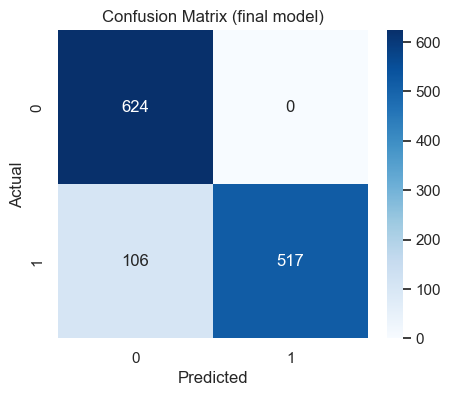

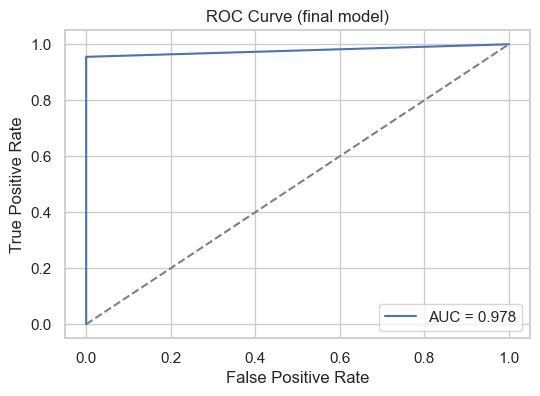

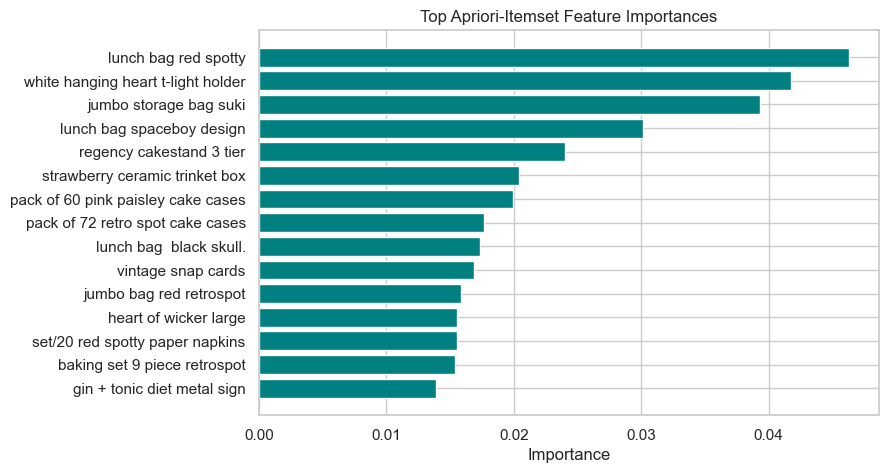


Total elapsed time: 406.5 s


In [14]:
# ---------- Visualizations ----------
# Confusion matrix
cm = confusion_matrix(y_test_full, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (final model)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.show()

# ROC curve
if y_prob is not None:
    fpr, tpr, _ = roc_curve(y_test_full, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (final model)"); plt.legend(); plt.show()

# Feature importance (map to itemsets)
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
    top_idx = np.argsort(importances)[-15:]
    top_itemsets = [', '.join(sorted(list(map(str, itemsets[i])))) for i in top_idx]
    top_scores = importances[top_idx]
    plt.figure(figsize=(8,5))
    plt.barh(range(len(top_idx)), top_scores, color='teal')
    plt.yticks(range(len(top_idx)), top_itemsets)
    plt.xlabel("Importance"); plt.title("Top Apriori-Itemset Feature Importances")
    plt.show()

elapsed = time.time() - start_time
print(f"\nTotal elapsed time: {elapsed:.1f} s")